In [13]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
from PIL import Image
import random
import sys
import os

In [3]:
IMG_SIZE = 224
MODEL_PATH = "waste_classifier_with_DenseNet201.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['O', 'R']

In [4]:
# FineTune Model Function: DenseNet201
def get_model():
    model = models.densenet201(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False  # Prevents the pre-trained weights from being updated during training.

    # Replace classifier
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 2)  # 2 classes: O, R
    )

    return model.to(DEVICE)

In [5]:
def load_trained_model(model_path):
    model = get_model()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    return model

In [6]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet Mean and Std
])

In [7]:
def predict_image(model, image_path, CLASS_NAMES):
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    
    transform = test_transform
    img_tensor = transform = test_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred_class = torch.argmax(output, dim=1).item()

    print(f"\n🧾 Prediction: {CLASS_NAMES[pred_class]}")
    return CLASS_NAMES[pred_class]

In [14]:
model = load_trained_model(MODEL_PATH)
image_paths = [ f'./test/test_image_{i}.png' for i in range(1,8)]
random.shuffle(image_paths)

d:\machine learning\machine_learning\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\machine learning\machine_learning\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


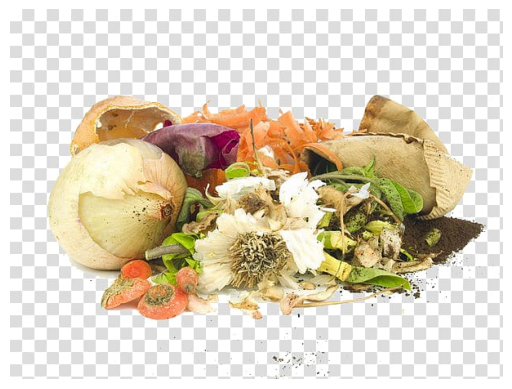


🧾 Prediction: O


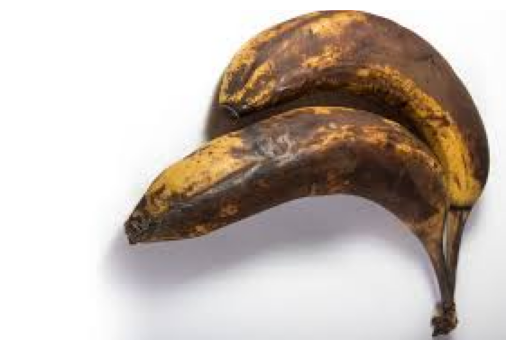


🧾 Prediction: O


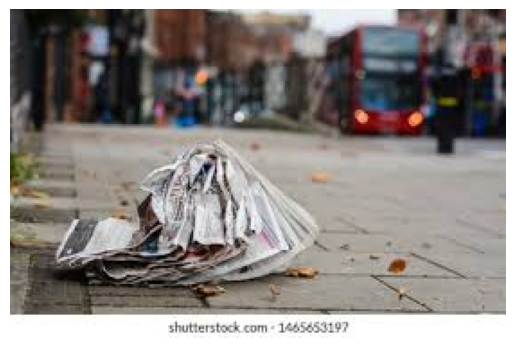


🧾 Prediction: R


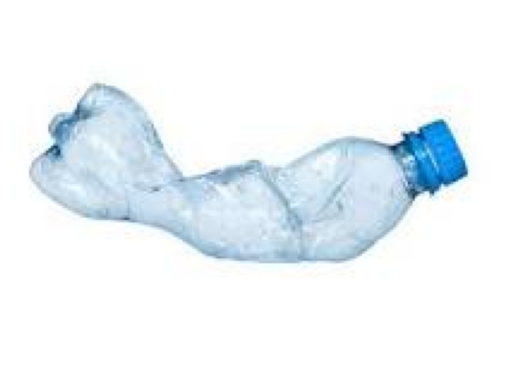


🧾 Prediction: R


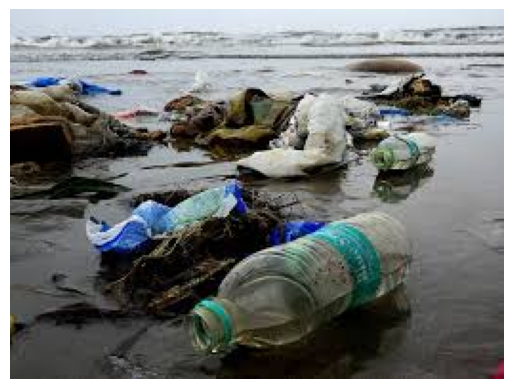


🧾 Prediction: R


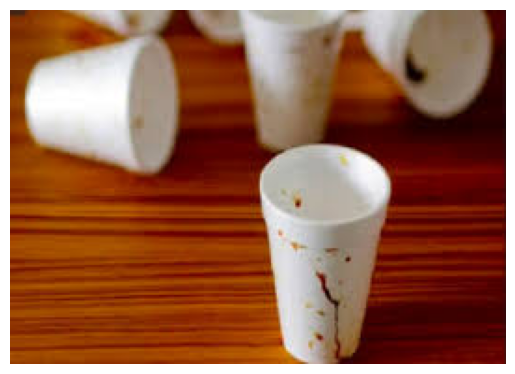


🧾 Prediction: R


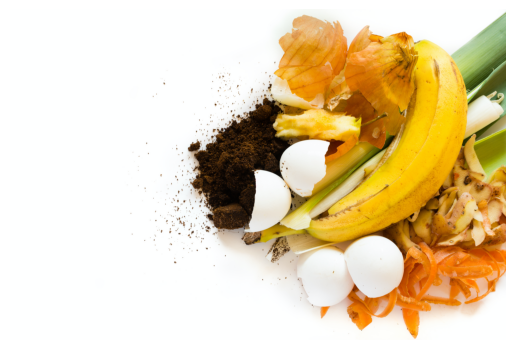


🧾 Prediction: O


In [15]:
for image_path in image_paths:
    predict_image(model, image_path, CLASS_NAMES)